<a href="https://colab.research.google.com/github/loicPf/test_ia/blob/main/deepLearning/FunctionalAPIMNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# import tensorflow.keras

# Loading the MNIST data

In [2]:
"""
from keras.datasets import mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
"""

'\nfrom keras.datasets import mnist\n(train_images, train_labels), (test_images, test_labels) = mnist.load_data()\n'

In [3]:
from keras.datasets import mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


# Preparing the data

In [20]:

train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype('float32') / 255
test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype('float32') / 255

from keras.utils import to_categorical
train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)


# Defining the network

In [21]:

from keras import models
from keras import layers
network = models.Sequential()
network.add(layers.Dense(512, activation='relu', input_shape=(28 * 28,)))
network.add(layers.Dense(10, activation='softmax'))


## The functional API: Defining the network

### creating an input node

In [28]:
from tensorflow import keras

# specify the shape of each data sample: 784-dimensional vectors
inputs = keras.Input(shape=(784,), name='img28')
# the batch size is always omitted: inputs = keras.Input(shape=(784,))

### information to feed the model

In [25]:
"""
inputs.shape = TensorShape([None, 784])
inputs.dtype = tf.float32
"""

'\ninputs.shape = TensorShape([None, 784])\ninputs.dtype = tf.float32\n'

### create a new node in the graph of layers

In [29]:
# calling a layer on this inputs object

from tensorflow.keras import layers

# drawing an arrow from "inputs" to this layer we created
dense = layers.Dense(64, activation='relu')
# "passing" the inputs to the dense layer, and out we get x
x = dense(inputs)

### add a few more layers to the graph of layers

In [30]:
x = layers.Dense(64, activation='relu')(x)
outputs = layers.Dense(10, activation='softmax')(x)

### create a Model by specifying its inputs and outputs in the graph of layers

In [31]:
# model = keras.Model(inputs=inputs, outputs=outputs)
model = keras.Model(inputs=inputs, outputs=outputs, name='mnist_model')

### full model definition process

In [11]:
"""
inputs = keras.Input(shape=(784,), name='img')
x = layers.Dense(64, activation='relu')(inputs)
x = layers.Dense(64, activation='relu')(x)
output = layers.Dense(10, activation='softmax')(x)

model = keras.Model(inputs=inputs, outputs=outputs, name='mnist_model')
"""

"\ninputs = keras.Input(shape=(784,), name='img')\nx = layers.Dense(64, activation='relu')(inputs)\nx = layers.Dense(64, activation='relu')(x)\noutput = layers.Dense(10, activation='softmax')(x)\n\nmodel = keras.Model(inputs=inputs, outputs=outputs, name='mnist_model')\n"

### plot the model as a graph

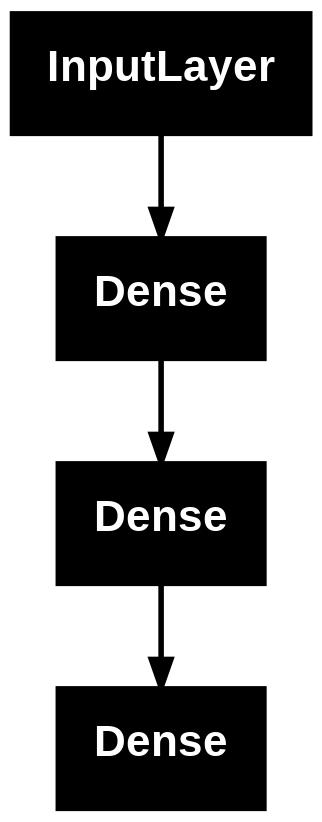

In [32]:
keras.utils.plot_model(model, 'my_first_model.png')

### display the input and output shapes of each layer

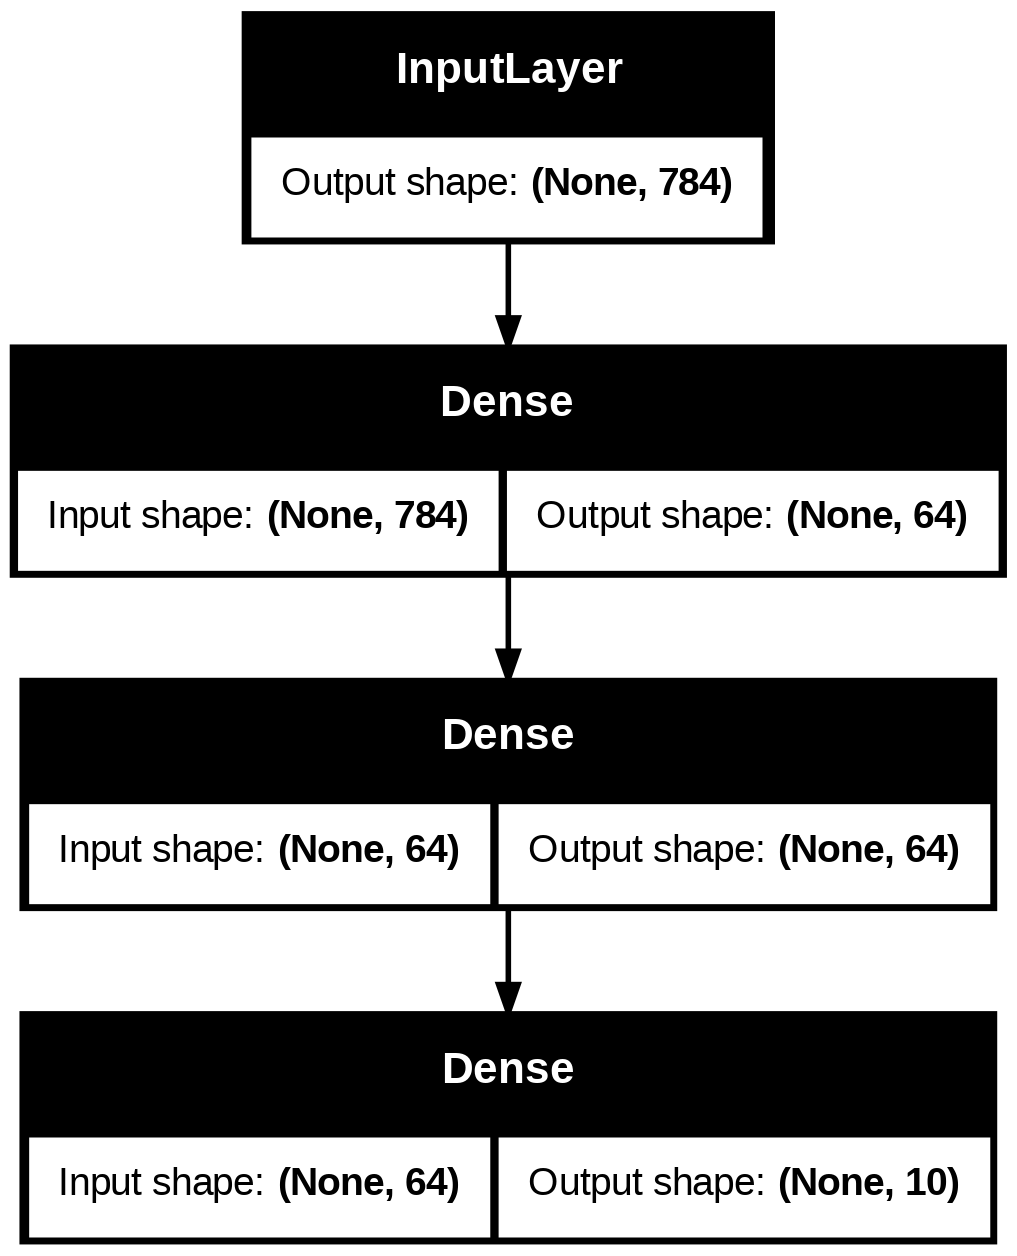

In [33]:
keras.utils.plot_model(model, 'my_fist_model_with_shape_info.png', \
                       show_shapes=True)

# Defining the optimizer and the loss

In [34]:

network.compile(optimizer='rmsprop', loss='categorical_crossentropy', \
                metrics=['accuracy'])

In [15]:
"""
network.compile(optimizer='rmsprop', loss='categorical_crossentropy', \
                metrics=['accuracy'])
"""

"\nnetwork.compile(optimizer='rmsprop', loss='categorical_crossentropy',                 metrics=['accuracy'])\n"

In [16]:
# Training the network

## TypeError: Unrecognized keyword arguments: {'natch_size': 128}

In [17]:
# network.fit(train_images, train_labels, epochs=5, natch_size=128)

## End of TypeError: Unrecognized keyword arguments: {'natch_size': 128}

In [35]:
network.fit(train_images, train_labels, epochs=5, batch_size=128)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8736 - loss: 0.4397
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9655 - loss: 0.1180
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9773 - loss: 0.0738
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9857 - loss: 0.0483
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9885 - loss: 0.0388


### Testing the network

In [36]:
test_loss, test_acc = network.evaluate(test_images, test_labels)
print('test_acc:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9763 - loss: 0.0759
test_acc: 0.980400025844574


# demo

In [38]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train = x_train.reshape(60000, 784).astype('float32') / 255
x_test = x_test.reshape(10000, 784).astype('float32') / 255

# 'sparse_categorical_crossentropy prend des entiers iso one-hot encoding
model.compile(loss='sparse_categorical_crossentropy',
              optimizer=keras.optimizers.RMSprop(),
              metrics=['accuracy'])
history = model.fit(x_train, y_train,
                    batch_size=64,
                    epochs=5,
                    validation_split=0.2)
test_scores = model.evaluate(x_test, y_test, verbose=2)
print('Test loss:', test_scores[0])
print('Test accuracy:', test_scores[1])

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8409 - loss: 0.5878 - val_accuracy: 0.9459 - val_loss: 0.1827
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9497 - loss: 0.1749 - val_accuracy: 0.9567 - val_loss: 0.1516
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9630 - loss: 0.1233 - val_accuracy: 0.9635 - val_loss: 0.1267
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9708 - loss: 0.0981 - val_accuracy: 0.9690 - val_loss: 0.1115
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9776 - loss: 0.0771 - val_accuracy: 0.9682 - val_loss: 0.1154
313/313 - 0s - 1ms/step - accuracy: 0.9689 - loss: 0.1015
Test loss: 0.10152041912078857
Test accuracy: 0.9689000248908997


# Saving and serialization

In [39]:
model.save('path_to_my_model.h5')

# Recreate the exact same model purely from the file
model = keras.models.load_model('path_to_my_model.h5')

# end-to-end autoencoder model for training

In [41]:
encoder_input = keras.Input(shape=(28, 28, 1), name='img')
x = layers.Conv2D(16, 3, activation='relu')(encoder_input)
x = layers.Conv2D(32, 3, activation='relu')(x)
x = layers.MaxPooling2D(3)(x)
x = layers.Conv2D(32, 3, activation='relu')(x)
x = layers.Conv2D(16, 3)

## predicting the class of an exemple

In [42]:
import matplotlib.pyplot as plt

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
[[0.07308971 0.09305489 0.09746066 0.06242364 0.09779011 0.20753324
  0.08221735 0.14168313 0.06359533 0.08115187]]


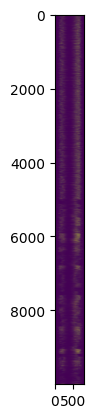

In [44]:
plt.imshow(test_images)
# img = test_images [0].reshape ((1, 28 * 28))
# il faut aussi faire la division par 255 si on prend les exemples de base
test_images = test_images.astype('float32') / 255
img = test_images[0].reshape((1, 28 * 28))
print(network.predict(img))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
[[4.3083286e-08 2.6670715e-09 8.4273097e-07 1.8931752e-05 2.5519781e-11
  2.4863219e-08 1.0673219e-12 9.9997902e-01 1.5313090e-07 9.9410545e-07]]


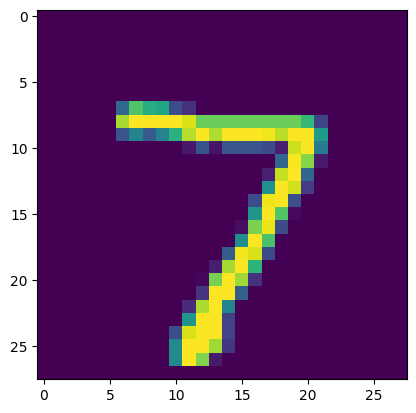

In [45]:
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
plt.imshow(test_images [0])
# img = test_images [0].reshape ((1, 28 * 28))
# il faut aussi faire la division par 255 si on prend les exemples de base
test_images = test_images.astype('float32') / 255
img = test_images[0].reshape((1, 28 * 28))
print(network.predict(img))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
[[4.3083286e-08 2.6670715e-09 8.4273097e-07 1.8931752e-05 2.5519781e-11
  2.4863219e-08 1.0673219e-12 9.9997902e-01 1.5313090e-07 9.9410545e-07]]


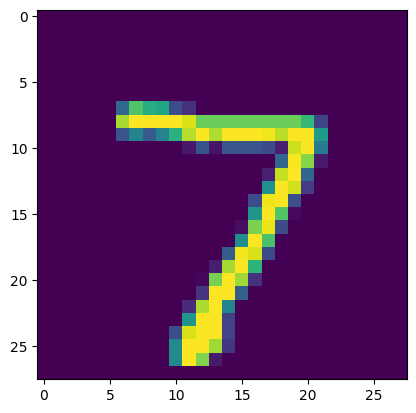

In [46]:
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
plt.imshow(test_images[0])
test_images = test_images.astype('float32') / 255
img = test_images[0].reshape((1, 28 * 28))
print(network.predict(img))